# 03. Experiment Tracking and Modeling

This notebook follows the Week 2 practical class flow, adapted to the Green Taxi project.

In the class notebooks, the workflow was:

1. Load a prepared dataset.
2. Import MLflow and set the tracking path.
3. Start an experiment.
4. Train a few models.
5. Log parameters, metrics, artifacts, and models.
6. Compare runs.
7. Use Optuna for hyperparameter tuning.

Here we use the same idea, but our target is `tip_amount`: the recorded tip amount for a Green Taxi credit-card trip.

## Business Problem

The project wants to build a reproducible MLOps workflow using NYC Green Taxi data.

For this modeling notebook, the prediction task is:

> Predict the tip amount for a credit-card Green Taxi trip.

This is a regression problem because the target is a numeric dollar amount. The model output is useful for comparing model families and practicing MLflow tracking before any serving-time feature decision is finalized.

## Loading the Data

Notebook 2 saves the prepared modeling datasets to `data/02_intermediate/train_data.parquet` and `data/02_intermediate/val_data.parquet`.

This notebook starts from those prepared datasets. It does not repeat the raw data cleaning and feature engineering steps.

In [1]:
from pathlib import Path
import importlib.metadata
import json
import platform
import warnings

import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ["MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING"] = "false"

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import optuna
import pandas as pd
from mlflow.models import infer_signature
from optuna.integration.mlflow import MLflowCallback

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "tip_amount"
MAX_TRAIN_ROWS_FOR_NOTEBOOK = 100_000
MAX_VALIDATION_ROWS_FOR_NOTEBOOK = 50_000
SKOPS_TRUSTED_TYPES = ["numpy.dtype"]
MLFLOW_MODEL_ENV = {
    "channels": ["conda-forge"],
    "dependencies": [
        f"python={platform.python_version()}",
        "pip>=24.0",
        {
            "pip": [
                f"mlflow=={mlflow.__version__}",
                f"scikit-learn=={importlib.metadata.version('scikit-learn')}",
                f"skops=={importlib.metadata.version('skops')}",
                f"pandas=={pd.__version__}",
                f"numpy=={importlib.metadata.version('numpy')}",
                f"scipy=={importlib.metadata.version('scipy')}",
            ]
        },
    ],
}

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

TRAIN_DATA_PATH = PROJECT_ROOT / "data" / "02_intermediate" / "train_data.parquet"
VAL_DATA_PATH = PROJECT_ROOT / "data" / "02_intermediate" / "val_data.parquet"
REPORTING_DIR = PROJECT_ROOT / "data" / "08_reporting" / "modeling"
REPORTING_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Train data path:", TRAIN_DATA_PATH)
print("Validation data path:", VAL_DATA_PATH)

Project root: c:\Users\Asus\Documents\MLOPS Project
Train data path: c:\Users\Asus\Documents\MLOPS Project\data\02_intermediate\train_data.parquet
Validation data path: c:\Users\Asus\Documents\MLOPS Project\data\02_intermediate\val_data.parquet


In [2]:
missing_paths = [path for path in [TRAIN_DATA_PATH, VAL_DATA_PATH] if not path.exists()]
if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        "Missing prepared data file(s). Run Notebook 2 first so it creates:\n"
        f"{missing_text}"
    )

train_df = pd.read_parquet(TRAIN_DATA_PATH)
val_df = pd.read_parquet(VAL_DATA_PATH)

if len(train_df) > MAX_TRAIN_ROWS_FOR_NOTEBOOK:
    train_df, _ = train_test_split(
        train_df,
        train_size=MAX_TRAIN_ROWS_FOR_NOTEBOOK,
        random_state=RANDOM_STATE,
    )
    train_df = train_df.reset_index(drop=True)

if len(val_df) > MAX_VALIDATION_ROWS_FOR_NOTEBOOK:
    val_df, _ = train_test_split(
        val_df,
        train_size=MAX_VALIDATION_ROWS_FOR_NOTEBOOK,
        random_state=RANDOM_STATE,
    )
    val_df = val_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
display(train_df.head())

target_summary = pd.DataFrame(
    {
        "train": train_df[TARGET_COL].describe(),
        "validation": val_df[TARGET_COL].describe(),
    }
).T
target_summary["zero_tip_share"] = [
    (train_df[TARGET_COL] == 0).mean(),
    (val_df[TARGET_COL] == 0).mean(),
]
display(target_summary)

Train shape: (100000, 21)
Validation shape: (50000, 21)


,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,trip_type,congestion_surcharge,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,1.0,95,135,1.0,1.96,12.1,1.0,0.5,3.65,0.00,...,1.0,0.00,9.166667,20,1,7,0,0,0,0
1,1.0,260,157,1.0,1.34,10.0,1.0,0.5,2.50,0.00,...,1.0,0.00,8.433333,21,3,6,0,0,0,0
2,1.0,244,152,1.0,1.74,12.8,0.0,0.5,2.50,0.00,...,1.0,0.00,11.616667,13,0,10,0,0,0,0
3,1.0,43,137,1.0,3.94,20.5,1.0,0.5,0.00,0.00,...,1.0,2.75,18.616667,23,3,5,0,0,1,0
4,2.0,74,132,1.0,17.44,70.0,5.0,0.5,8.00,6.94,...,1.0,0.00,47.616667,16,3,12,0,0,0,1


,count,mean,std,min,25%,50%,75%,max,zero_tip_share
train,100000.0,3.651965,3.248156,0.0,2.0,3.00,4.61,130.0,0.08339
validation,50000.0,3.873083,3.612829,0.0,2.0,3.14,4.81,151.5,0.08260


# Import mlflow and set the tracking to the right path

This mirrors the Week 2 notebook section where MLflow tracking is configured before starting experiments.

Instead of using a remote tracking server, we use a local `mlruns/` folder inside the project.

In [3]:
TRACKING_DIR = PROJECT_ROOT / "mlruns"
mlflow.set_tracking_uri(TRACKING_DIR.as_uri())

EXPERIMENT_NAME = "green_taxi_tip_amount_week2_flow"
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", EXPERIMENT_NAME)

MLflow tracking URI: file:///c:/Users/Asus/Documents/MLOPS%20Project/mlruns
Experiment name: green_taxi_tip_amount_week2_flow


# Starting an experiment

Before training models, we define `X_train`, `X_val`, `y_train`, and `y_val`, then create one preprocessing object that all models will use.

This is the Green Taxi equivalent of preparing train and validation inputs in the Week 2 notebooks.

In [4]:
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL].astype(float)

X_val = val_df.drop(columns=[TARGET_COL])
y_val = val_df[TARGET_COL].astype(float)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Mean tip in train:", round(y_train.mean(), 2))
print("Mean tip in validation:", round(y_val.mean(), 2))
print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Train shape: (100000, 20)
Validation shape: (50000, 20)
Mean tip in train: 3.65
Mean tip in validation: 3.87
Numeric features: 20
Categorical features: []


In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

# Choose 3 models

The Week 2 problem notebook asks us to choose three models and log different metrics.

Here we use:

1. `DummyRegressor`: a trivial baseline that predicts the median tip.
2. `Ridge`: a simple linear regression model.
3. `RandomForestRegressor`: a tree-based regression model.

The dummy model is important because it tells us whether the real models are actually better than a naive strategy.

In [6]:
models = {
    "dummy_median": {
        "model": DummyRegressor(strategy="median"),
        "params": {"strategy": "median"},
        "description": "Naive baseline that always predicts the median tip amount.",
    },
    "ridge_regression": {
        "model": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "params": {"alpha": 1.0},
        "description": "Simple regularized linear regression model.",
    },
    "random_forest_regressor": {
        "model": RandomForestRegressor(
            n_estimators=80,
            max_depth=12,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "params": {
            "n_estimators": 80,
            "max_depth": 12,
            "min_samples_leaf": 20,
        },
        "description": "Tree-based regression model that can capture non-linear patterns.",
    },
}

# Logging relevant parameters with MLflow tracking

This section is the direct equivalent of the Week 2 MLflow logging cells.

For each model, we log:

- model parameters;
- regression metrics;
- validation predictions;
- an actual-versus-predicted plot;
- a residual plot;
- the trained sklearn pipeline using MLflow's `skops` serialization format.

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "median_ae": median_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


run_rows = []
trained_models = {}

for model_name, model_info in models.items():
    regressor = model_info["model"]
    params = model_info["params"]
    description = model_info["description"]

    full_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", regressor),
        ]
    )

    with mlflow.start_run(run_name=model_name, description=description) as run:
        full_model.fit(X_train, y_train)

        y_pred = full_model.predict(X_val)
        metrics = regression_metrics(y_val, y_pred)

        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.set_tags(
            {
                "project": "green_taxi_mlops",
                "target": TARGET_COL,
                "task": "regression",
                "stage": "baseline_model_comparison",
            }
        )

        metrics_path = REPORTING_DIR / f"{model_name}_metrics.json"
        with metrics_path.open("w", encoding="utf-8") as f:
            json.dump(metrics, f, indent=2)
        mlflow.log_artifact(str(metrics_path), artifact_path="reports")

        predictions = pd.DataFrame(
            {
                "actual_tip_amount": y_val.reset_index(drop=True),
                "predicted_tip_amount": y_pred,
                "residual": y_val.reset_index(drop=True) - y_pred,
            }
        )
        predictions_path = REPORTING_DIR / f"{model_name}_validation_predictions.csv"
        predictions.to_csv(predictions_path, index=False)
        mlflow.log_artifact(str(predictions_path), artifact_path="predictions")

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(predictions["actual_tip_amount"], predictions["predicted_tip_amount"], alpha=0.25, s=10)
        max_tip = max(predictions["actual_tip_amount"].max(), predictions["predicted_tip_amount"].max())
        ax.plot([0, max_tip], [0, max_tip], color="black", linewidth=1)
        ax.set_title(model_name)
        ax.set_xlabel("Actual tip amount")
        ax.set_ylabel("Predicted tip amount")
        actual_pred_path = REPORTING_DIR / f"{model_name}_actual_vs_predicted.png"
        fig.tight_layout()
        fig.savefig(actual_pred_path, dpi=150)
        plt.close(fig)
        mlflow.log_artifact(str(actual_pred_path), artifact_path="figures")

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(predictions["residual"], bins=40, color="steelblue", edgecolor="white")
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"Residuals: {model_name}")
        ax.set_xlabel("Actual - predicted tip amount")
        ax.set_ylabel("Trip count")
        residual_path = REPORTING_DIR / f"{model_name}_residuals.png"
        fig.tight_layout()
        fig.savefig(residual_path, dpi=150)
        plt.close(fig)
        mlflow.log_artifact(str(residual_path), artifact_path="figures")

        signature = infer_signature(X_train.head(20), full_model.predict(X_train.head(20)))
        mlflow.sklearn.log_model(
            sk_model=full_model,
            name="model",
            signature=signature,
            input_example=X_train.head(3),
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            skops_trusted_types=SKOPS_TRUSTED_TYPES,
            conda_env=MLFLOW_MODEL_ENV,
        )

        run_rows.append(
            {
                "model": model_name,
                "run_id": run.info.run_id,
                "artifact_uri": run.info.artifact_uri,
                "description": description,
                **metrics,
            }
        )
        trained_models[model_name] = full_model

runs_df = pd.DataFrame(run_rows).sort_values("rmse", ascending=True)
display(runs_df)

,model,run_id,artifact_uri,description,mae,rmse,median_ae,r2
2,random_forest_regressor,00724bfcbc164918b179cf0368d82fa7,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Tree-based regression model that can capture n...,1.466908,2.814989,0.791469,0.392890
1,ridge_regression,137c08f05e054b0eb3f15d1bcc804873,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Simple regularized linear regression model.,1.475700,2.831265,0.785521,0.385849
0,dummy_median,f23edf4833ed40af95bd88d11fbeb168,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Naive baseline that always predicts the median...,2.094514,3.716793,1.200000,-0.058402


# Create a pandas dataframe with experiment information

This mirrors the Week 2 exercise asking for a dataframe with experiment/run information.

The important columns are:

- `run_id`: MLflow run identifier;
- `artifact_uri`: where the model/artifacts were stored;
- regression metrics such as `mae`, `rmse`, and `r2`.

In [8]:
baseline_comparison_path = REPORTING_DIR / "baseline_mlflow_runs.csv"
runs_df.to_csv(baseline_comparison_path, index=False)

display(runs_df[["model", "run_id", "artifact_uri", "mae", "rmse", "median_ae", "r2", "description"]])
print("Saved run comparison to:", baseline_comparison_path)

,model,run_id,artifact_uri,mae,rmse,median_ae,r2,description
2,random_forest_regressor,00724bfcbc164918b179cf0368d82fa7,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,1.466908,2.814989,0.791469,0.392890,Tree-based regression model that can capture n...
1,ridge_regression,137c08f05e054b0eb3f15d1bcc804873,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,1.475700,2.831265,0.785521,0.385849,Simple regularized linear regression model.
0,dummy_median,f23edf4833ed40af95bd88d11fbeb168,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,2.094514,3.716793,1.200000,-0.058402,Naive baseline that always predicts the median...


Saved run comparison to: c:\Users\Asus\Documents\MLOPS Project\data\08_reporting\modeling\baseline_mlflow_runs.csv


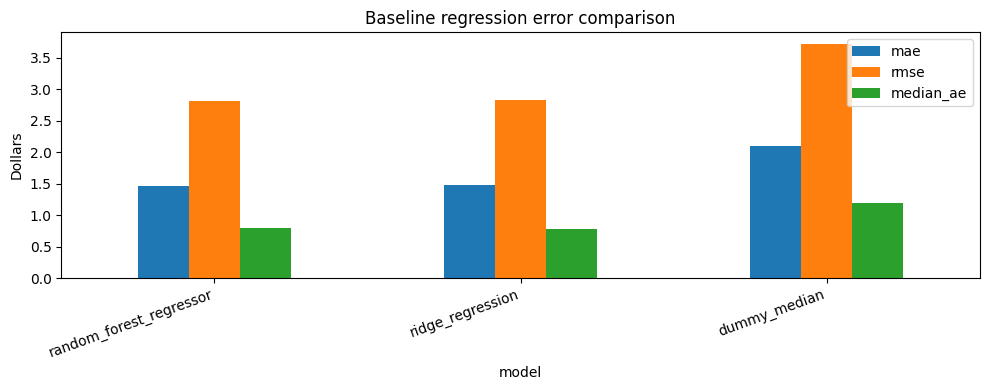

,model,r2
2,random_forest_regressor,0.392890
1,ridge_regression,0.385849
0,dummy_median,-0.058402


In [9]:
error_metric_columns = ["mae", "rmse", "median_ae"]

ax = runs_df.set_index("model")[error_metric_columns].plot(
    kind="bar",
    figsize=(10, 4),
)
ax.set_title("Baseline regression error comparison")
ax.set_ylabel("Dollars")
ax.legend(loc="upper right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(runs_df[["model", "r2"]])

# Hyperparameter fine-tuning with MLflow tracking

This mirrors the Optuna part of the Week 2 class.

Optuna tries different hyperparameter combinations. Each trial trains a model and returns one score. Here the score is validation `rmse`, because lower dollar error is easier to explain for a tip amount regression task.

We tune only the random forest because it is the most flexible baseline model.

In [10]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 40, 120, step=40),
        "max_depth": trial.suggest_int("max_depth", 4, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", RandomForestRegressor(**params)),
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    return root_mean_squared_error(y_val, y_pred)

In [11]:
mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="rmse",
    mlflow_kwargs={"nested": True},
)

study = optuna.create_study(
    study_name="green_taxi_random_forest_rmse",
    direction="minimize",
)

with mlflow.start_run(run_name="optuna_random_forest_parent") as parent_run:
    mlflow.set_tags(
        {
            "project": "green_taxi_mlops",
            "target": TARGET_COL,
            "stage": "optuna_tuning",
            "model_family": "random_forest_regressor",
        }
    )

    study.optimize(objective, n_trials=8, callbacks=[mlflow_callback])

    mlflow.log_metric("best_rmse", study.best_value)
    mlflow.log_params({f"best_{key}": value for key, value in study.best_params.items()})

print("Best Optuna RMSE:", round(study.best_value, 4))
print("Best parameters:")
study.best_params

[I 2026-06-26 00:42:42,877] A new study created in memory with name: green_taxi_random_forest_rmse
[I 2026-06-26 00:42:43,729] Trial 0 finished with value: 2.83057261616181 and parameters: {'n_estimators': 40, 'max_depth': 7, 'min_samples_leaf': 48, 'max_features': 'log2'}. Best is trial 0 with value: 2.83057261616181.
[I 2026-06-26 00:42:49,904] Trial 1 finished with value: 2.815227386650078 and parameters: {'n_estimators': 120, 'max_depth': 10, 'min_samples_leaf': 45, 'max_features': 1.0}. Best is trial 1 with value: 2.815227386650078.
[I 2026-06-26 00:42:56,819] Trial 2 finished with value: 2.8213635461600943 and parameters: {'n_estimators': 120, 'max_depth': 12, 'min_samples_leaf': 6, 'max_features': 1.0}. Best is trial 1 with value: 2.815227386650078.
[I 2026-06-26 00:42:58,104] Trial 3 finished with value: 2.8278950260877433 and parameters: {'n_estimators': 80, 'max_depth': 7, 'min_samples_leaf': 31, 'max_features': 'sqrt'}. Best is trial 1 with value: 2.815227386650078.
[I 2026-

Best Optuna RMSE: 2.8093
Best parameters:


{'n_estimators': 120,
 'max_depth': 11,
 'min_samples_leaf': 12,
 'max_features': 'log2'}

# Register your best model

In the class notebook, this section registers the selected model.

For this student project, we first log the best tuned model clearly. Registering it in the MLflow Model Registry can be added after the team agrees that this is the candidate model for serving.

In [12]:
best_params = {
    **study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

best_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(**best_params)),
    ]
)

with mlflow.start_run(run_name="best_optuna_random_forest_regressor") as run:
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_val)
    best_metrics = regression_metrics(y_val, y_pred)

    mlflow.log_params(best_params)
    mlflow.log_metrics(best_metrics)
    mlflow.set_tags(
        {
            "project": "green_taxi_mlops",
            "target": TARGET_COL,
            "stage": "best_tuned_model",
            "optimizer": "optuna",
            "task": "regression",
        }
    )

    best_predictions = pd.DataFrame(
        {
            "actual_tip_amount": y_val.reset_index(drop=True),
            "predicted_tip_amount": y_pred,
            "residual": y_val.reset_index(drop=True) - y_pred,
        }
    )
    best_predictions_path = REPORTING_DIR / "best_optuna_random_forest_validation_predictions.csv"
    best_predictions.to_csv(best_predictions_path, index=False)
    mlflow.log_artifact(str(best_predictions_path), artifact_path="predictions")

    signature = infer_signature(X_train.head(20), best_model.predict(X_train.head(20)))
    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="model",
        signature=signature,
        input_example=X_train.head(3),
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
        skops_trusted_types=SKOPS_TRUSTED_TYPES,
        conda_env=MLFLOW_MODEL_ENV,
    )

    best_run_id = run.info.run_id
    best_artifact_uri = run.info.artifact_uri

print("Best tuned model run id:", best_run_id)
print("Best tuned model artifact URI:", best_artifact_uri)
print(best_metrics)

Best tuned model run id: 79c0b1ccab5c444d9427e17d1c2c8384
Best tuned model artifact URI: file:///C:/Users/Asus/Documents/MLOPS%20Project/mlruns/606582310450648764/79c0b1ccab5c444d9427e17d1c2c8384/artifacts
{'mae': 1.46880477439988, 'rmse': 2.809347036379333, 'median_ae': 0.796614344855332, 'r2': 0.3953214544395919}


# Final MLflow runs table

This final table keeps the same spirit as the Week 2 exercise: collect the most relevant experiment information in a pandas dataframe and rank the regression runs by validation RMSE.

In [13]:
best_row = {
    "model": "best_optuna_random_forest_regressor",
    "run_id": best_run_id,
    "artifact_uri": best_artifact_uri,
    "description": "Random forest regressor tuned with Optuna.",
    **best_metrics,
}

final_runs_df = pd.concat(
    [runs_df, pd.DataFrame([best_row])],
    ignore_index=True,
).sort_values("rmse", ascending=True)

final_runs_path = REPORTING_DIR / "final_mlflow_runs_summary.csv"
final_runs_df.to_csv(final_runs_path, index=False)

display(final_runs_df)
print("Saved final MLflow runs summary to:", final_runs_path)

,model,run_id,artifact_uri,description,mae,rmse,median_ae,r2
3,best_optuna_random_forest_regressor,79c0b1ccab5c444d9427e17d1c2c8384,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Random forest regressor tuned with Optuna.,1.468805,2.809347,0.796614,0.395321
0,random_forest_regressor,00724bfcbc164918b179cf0368d82fa7,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Tree-based regression model that can capture n...,1.466908,2.814989,0.791469,0.392890
1,ridge_regression,137c08f05e054b0eb3f15d1bcc804873,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Simple regularized linear regression model.,1.475700,2.831265,0.785521,0.385849
2,dummy_median,f23edf4833ed40af95bd88d11fbeb168,file:///C:/Users/Asus/Documents/MLOPS%20Projec...,Naive baseline that always predicts the median...,2.094514,3.716793,1.200000,-0.058402


Saved final MLflow runs summary to: c:\Users\Asus\Documents\MLOPS Project\data\08_reporting\modeling\final_mlflow_runs_summary.csv


## Conclusions

- This notebook follows the Week 2 class structure: MLflow setup, experiment start, three models, logged metrics/artifacts, run comparison, Optuna tuning, and best model logging.
- The Green Taxi adaptation uses `tip_amount` as a regression target.
- The most important comparison metric here is `rmse`, because it reports typical prediction error in dollars and lower values are better.
- The stable parts of this notebook can later be moved into a Kedro `model_train` pipeline.
- Before serving, the team still needs to confirm whether all features are available at the intended prediction time.